# 02 — Feature Extraction & Nail-Bed Analysis

## Objectives
1. Crop nail & skin ROIs using bounding boxes from metadata
2. Analyze color-space distributions (RGB, LAB, HSV) of nail ROIs
3. Compute per-channel statistics and their correlation with Hb levels
4. Compute nail-vs-skin contrast features
5. Export feature matrix for baseline modeling

In [1]:
import ast
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_ROOT = Path("../data/raw")
METADATA_CSV = DATA_ROOT / "metadata.csv"
PHOTO_DIR = DATA_ROOT / "photo"
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load metadata
df = pd.read_csv(METADATA_CSV)
df["NAIL_BOUNDING_BOXES"] = df["NAIL_BOUNDING_BOXES"].apply(ast.literal_eval)
df["SKIN_BOUNDING_BOXES"] = df["SKIN_BOUNDING_BOXES"].apply(ast.literal_eval)
df["hb_gdL"] = df["HB_LEVEL_GperL"] / 10.0
df["image_path"] = df["PATIENT_ID"].apply(lambda pid: PHOTO_DIR / f"{pid}.jpg")
df["image_exists"] = df["image_path"].apply(lambda p: p.exists())

valid_df = df[df["image_exists"]].copy().reset_index(drop=True)
print(f"Working with {len(valid_df)} valid samples")

Working with 250 valid samples


## 1. ROI Extraction Using Provided Bounding Boxes

Each sample comes with 3 nail bounding boxes and 3 skin bounding boxes. We crop each ROI and compute color features. This avoids unreliable auto-detection.

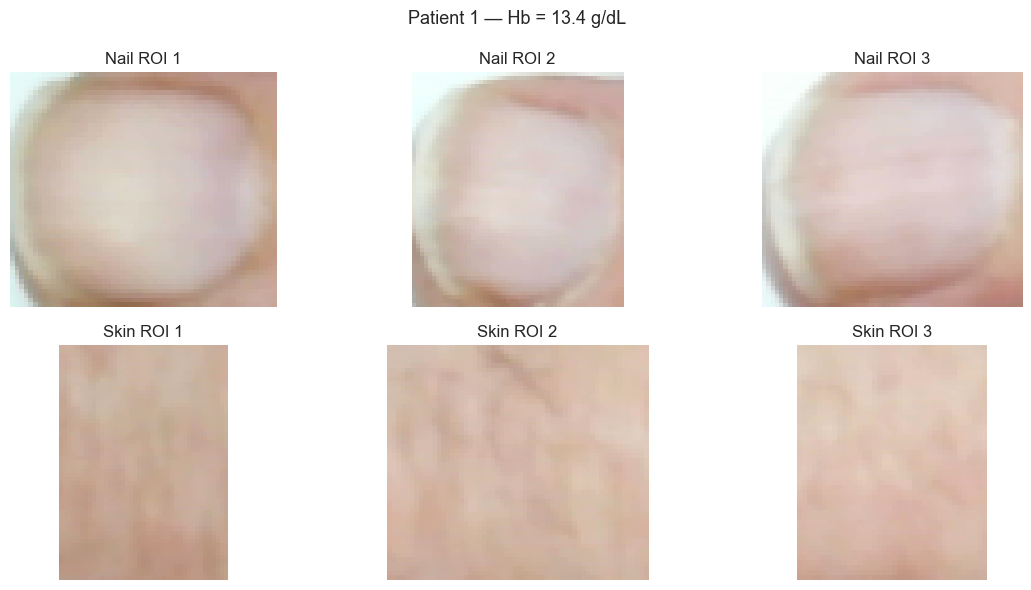

In [2]:
def crop_roi(image: np.ndarray, bbox: list) -> np.ndarray:
    """Crop a region from image given [ymin, xmin, ymax, xmax] bounding box."""
    ymin, xmin, ymax, xmax = bbox
    h, w = image.shape[:2]
    ymin, xmin = max(0, ymin), max(0, xmin)
    ymax, xmax = min(h, ymax), min(w, xmax)
    return image[ymin:ymax, xmin:xmax]


def extract_color_features(roi: np.ndarray, prefix: str = "") -> dict:
    """
    Compute per-channel mean, std, median, and percentiles
    in RGB, LAB, and HSV color spaces.
    """
    if roi.size == 0:
        return {}
    
    features = {}
    
    # RGB (OpenCV loads as BGR, convert)
    rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    for i, ch in enumerate(["R", "G", "B"]):
        vals = rgb[:, :, i].astype(float)
        features[f"{prefix}rgb_{ch}_mean"] = vals.mean()
        features[f"{prefix}rgb_{ch}_std"] = vals.std()
        features[f"{prefix}rgb_{ch}_median"] = np.median(vals)
    
    # LAB
    lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
    for i, ch in enumerate(["L", "A", "B_lab"]):
        vals = lab[:, :, i].astype(float)
        features[f"{prefix}lab_{ch}_mean"] = vals.mean()
        features[f"{prefix}lab_{ch}_std"] = vals.std()
    
    # HSV
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    for i, ch in enumerate(["H", "S", "V"]):
        vals = hsv[:, :, i].astype(float)
        features[f"{prefix}hsv_{ch}_mean"] = vals.mean()
        features[f"{prefix}hsv_{ch}_std"] = vals.std()
    
    return features


# Visualize a few ROI crops
sample_row = valid_df.iloc[0]
img = cv2.imread(str(sample_row["image_path"]))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for j, bbox in enumerate(sample_row["NAIL_BOUNDING_BOXES"]):
    roi = crop_roi(img, bbox)
    axes[0][j].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[0][j].set_title(f"Nail ROI {j+1}")
    axes[0][j].axis("off")
for j, bbox in enumerate(sample_row["SKIN_BOUNDING_BOXES"]):
    roi = crop_roi(img, bbox)
    axes[1][j].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[1][j].set_title(f"Skin ROI {j+1}")
    axes[1][j].axis("off")

plt.suptitle(f"Patient {sample_row['PATIENT_ID']} — Hb = {sample_row['hb_gdL']:.1f} g/dL", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Full Feature Extraction Pipeline

For each sample, we:
1. Crop all 3 nail ROIs → compute color features → average across the 3
2. Crop all 3 skin ROIs → compute color features → average across the 3
3. Compute **nail-vs-skin contrast** features (difference of nail and skin means)

In [3]:
def extract_sample_features(row) -> dict:
    """Extract all features for one sample (averaged across 3 nail & 3 skin ROIs)."""
    img = cv2.imread(str(row["image_path"]))
    if img is None:
        return {}
    
    # Nail features (average over 3 ROIs)
    nail_feats_list = []
    for bbox in row["NAIL_BOUNDING_BOXES"]:
        roi = crop_roi(img, bbox)
        if roi.size > 0:
            nail_feats_list.append(extract_color_features(roi, prefix="nail_"))
    
    # Skin features (average over 3 ROIs)
    skin_feats_list = []
    for bbox in row["SKIN_BOUNDING_BOXES"]:
        roi = crop_roi(img, bbox)
        if roi.size > 0:
            skin_feats_list.append(extract_color_features(roi, prefix="skin_"))
    
    features = {}
    
    # Average nail features
    if nail_feats_list:
        nail_df = pd.DataFrame(nail_feats_list)
        for col in nail_df.columns:
            features[col] = nail_df[col].mean()
    
    # Average skin features
    if skin_feats_list:
        skin_df = pd.DataFrame(skin_feats_list)
        for col in skin_df.columns:
            features[col] = skin_df[col].mean()
    
    # Contrast features: nail - skin (for mean channels)
    nail_mean_keys = [k for k in features if k.startswith("nail_") and "_mean" in k]
    for nk in nail_mean_keys:
        sk = nk.replace("nail_", "skin_")
        if sk in features:
            contrast_key = nk.replace("nail_", "contrast_")
            features[contrast_key] = features[nk] - features[sk]
    
    return features


# Run extraction on all valid samples
all_features = []
for idx, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc="Extracting features"):
    feats = extract_sample_features(row)
    feats["PATIENT_ID"] = row["PATIENT_ID"]
    feats["hb_gdL"] = row["hb_gdL"]
    feats["HB_LEVEL_GperL"] = row["HB_LEVEL_GperL"]
    all_features.append(feats)

features_df = pd.DataFrame(all_features)
print(f"\nFeature matrix: {features_df.shape}")
print(f"Feature columns: {len([c for c in features_df.columns if c not in ['PATIENT_ID', 'hb_gdL', 'HB_LEVEL_GperL']])}")
display(features_df.head())

Extracting features:   0%|          | 0/250 [00:00<?, ?it/s]


Feature matrix: (250, 54)
Feature columns: 51


,nail_rgb_R_mean,nail_rgb_R_std,nail_rgb_R_median,nail_rgb_G_mean,nail_rgb_G_std,nail_rgb_G_median,nail_rgb_B_mean,nail_rgb_B_std,nail_rgb_B_median,nail_lab_L_mean,...,contrast_rgb_B_mean,contrast_lab_L_mean,contrast_lab_A_mean,contrast_lab_B_lab_mean,contrast_hsv_H_mean,contrast_hsv_S_mean,contrast_hsv_V_mean,PATIENT_ID,hb_gdL,HB_LEVEL_GperL
0,206.850359,14.816578,209.000000,188.748714,24.746427,191.666667,179.537315,28.724826,185.000000,198.341559,...,16.070595,5.635511,-2.545109,-5.371684,11.020198,-19.548960,-1.469038,1,13.4,134.0
1,212.280886,12.808156,213.666667,175.258546,22.332687,173.666667,162.282019,26.396711,163.000000,189.978600,...,22.000289,1.460463,4.427111,-10.978245,-5.320492,-23.049994,2.855422,2,10.8,108.0
2,221.970940,13.565961,224.666667,197.110102,21.795308,201.500000,187.851617,27.165819,195.666667,207.601605,...,-0.070173,-15.512644,6.704938,-8.560242,8.026997,-8.713188,-11.026508,5,8.4,84.0
3,193.224729,16.322717,194.666667,166.851747,27.045026,174.333333,154.290147,32.784345,162.333333,179.493554,...,24.394748,6.704111,-2.733688,-9.593351,-0.827608,-33.470795,-3.054663,6,13.8,138.0
4,192.709765,18.504612,196.333333,168.199971,26.784294,172.000000,160.927040,28.050778,165.000000,180.558299,...,18.065052,6.758473,-3.836177,-6.031606,-0.509756,-25.299535,-3.001252,7,11.9,119.0


## 3. Correlation Analysis

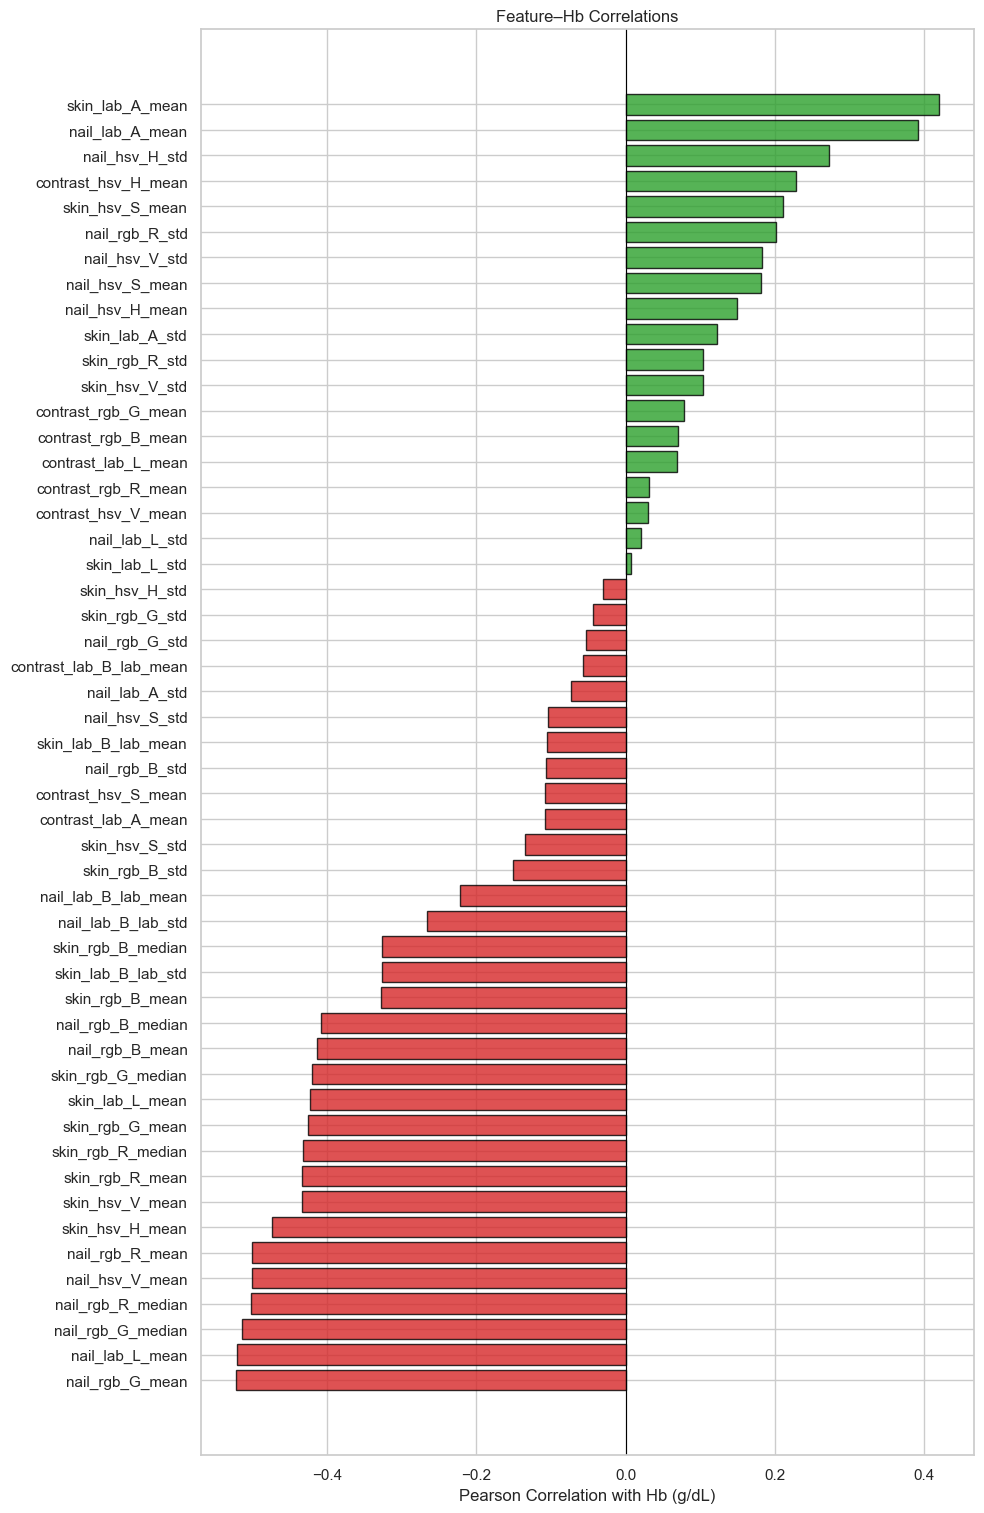


Top 10 features by |correlation|:
  nail_rgb_G_mean                      r = -0.522
  nail_lab_L_mean                      r = -0.521
  nail_rgb_G_median                    r = -0.515
  nail_rgb_R_median                    r = -0.501
  nail_hsv_V_mean                      r = -0.501
  nail_rgb_R_mean                      r = -0.500
  skin_hsv_H_mean                      r = -0.473
  skin_hsv_V_mean                      r = -0.434
  skin_rgb_R_mean                      r = -0.434
  skin_rgb_R_median                    r = -0.432


In [4]:
# Compute correlations between features and Hb
feat_cols = [c for c in features_df.columns if c not in ["PATIENT_ID", "hb_gdL", "HB_LEVEL_GperL"]]

correlations = features_df[feat_cols].corrwith(features_df["hb_gdL"]).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(feat_cols) * 0.3)))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor="black", alpha=0.8)
ax.set_xlabel("Pearson Correlation with Hb (g/dL)")
ax.set_title("Feature–Hb Correlations")
ax.axvline(x=0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

# Top 10 most correlated features (absolute)
print("\nTop 10 features by |correlation|:")
top10 = correlations.abs().sort_values(ascending=False).head(10)
for feat_name, corr_val in top10.items():
    sign = "+" if correlations[feat_name] > 0 else "-"
    print(f"  {feat_name:35s}  r = {sign}{corr_val:.3f}")

## 4. Scatter Plots — Top Features vs Hb

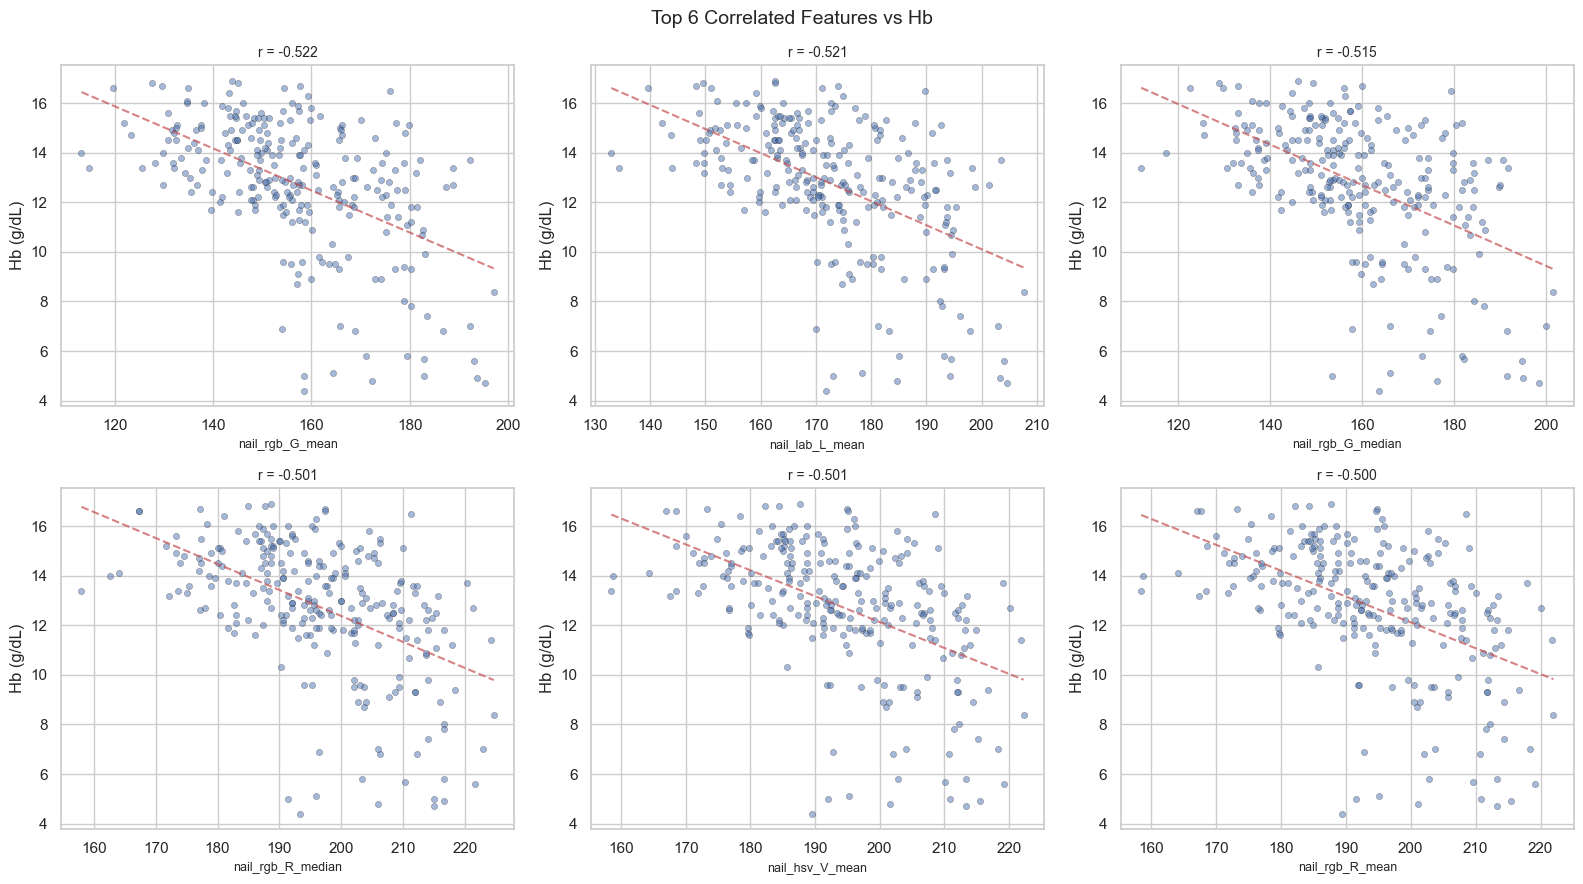

In [5]:
# Scatter plots for top 6 features
top6_feats = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(top6_feats):
    ax = axes[i // 3][i % 3]
    ax.scatter(features_df[feat], features_df["hb_gdL"], alpha=0.5, s=20, edgecolors="black", linewidth=0.3)
    r = correlations[feat]
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("Hb (g/dL)")
    ax.set_title(f"r = {r:.3f}", fontsize=10)
    # Trend line
    z = np.polyfit(features_df[feat].dropna(), features_df.loc[features_df[feat].notna(), "hb_gdL"], 1)
    x_line = np.linspace(features_df[feat].min(), features_df[feat].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "r--", alpha=0.7)

plt.suptitle("Top 6 Correlated Features vs Hb", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Export Feature Matrix

In [6]:
# Save for use in 03_baseline_models.ipynb
output_path = OUTPUT_DIR / "color_features.csv"
features_df.to_csv(output_path, index=False)
print(f"Saved feature matrix to {output_path}")
print(f"  Shape: {features_df.shape}")
print(f"  Columns: {list(features_df.columns)}")

Saved feature matrix to ..\data\processed\color_features.csv
  Shape: (250, 54)
  Columns: ['nail_rgb_R_mean', 'nail_rgb_R_std', 'nail_rgb_R_median', 'nail_rgb_G_mean', 'nail_rgb_G_std', 'nail_rgb_G_median', 'nail_rgb_B_mean', 'nail_rgb_B_std', 'nail_rgb_B_median', 'nail_lab_L_mean', 'nail_lab_L_std', 'nail_lab_A_mean', 'nail_lab_A_std', 'nail_lab_B_lab_mean', 'nail_lab_B_lab_std', 'nail_hsv_H_mean', 'nail_hsv_H_std', 'nail_hsv_S_mean', 'nail_hsv_S_std', 'nail_hsv_V_mean', 'nail_hsv_V_std', 'skin_rgb_R_mean', 'skin_rgb_R_std', 'skin_rgb_R_median', 'skin_rgb_G_mean', 'skin_rgb_G_std', 'skin_rgb_G_median', 'skin_rgb_B_mean', 'skin_rgb_B_std', 'skin_rgb_B_median', 'skin_lab_L_mean', 'skin_lab_L_std', 'skin_lab_A_mean', 'skin_lab_A_std', 'skin_lab_B_lab_mean', 'skin_lab_B_lab_std', 'skin_hsv_H_mean', 'skin_hsv_H_std', 'skin_hsv_S_mean', 'skin_hsv_S_std', 'skin_hsv_V_mean', 'skin_hsv_V_std', 'contrast_rgb_R_mean', 'contrast_rgb_G_mean', 'contrast_rgb_B_mean', 'contrast_lab_L_mean', 'contras